
Gravity Details

Acceleration of gravity at surface level:    9.7958 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5554 m/s²


Launch Site Details

Launch Date: 2026-05-24 15:00:00 UTC | 2026-05-24 08:00:00 US/Pacific
Launch Site Latitude: 35.34660°
Launch Site Longitude: -117.80900°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 426489.24 W    3911781.04 N
Launch Site UTM zone: 11S
Launch Site Surface Elevation: 609.6 m


Atmospheric Model Details

Atmospheric Model Type: custom_atmosphere
custom_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.71 m/s
Surface Wind Direction: 270.81°
Surface Wind Heading: 90.81°
Surface Pressure: 942.90 hPa
Surface Temperature: 293.97 K
Surface Air Density: 1.117 kg/m³
Surface Speed of Sound: 343.71 m/s


Earth Model Details

Earth Radius at Launch site: 6371.02 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



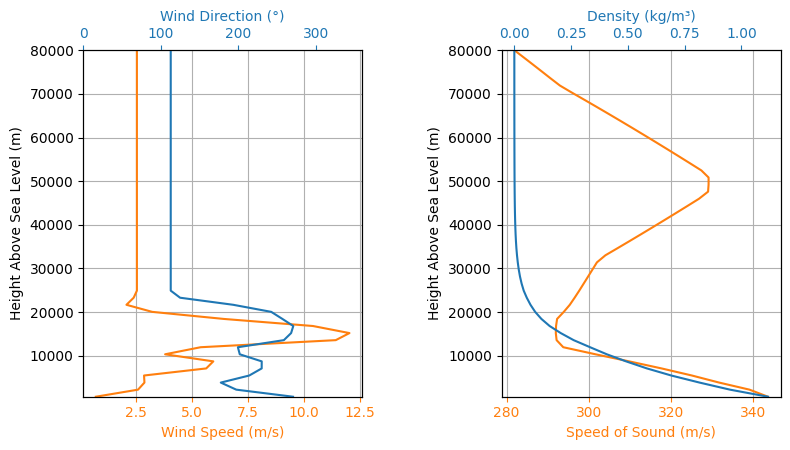

Nozzle Details
Nozzle Radius: 0.025 m
Nozzle Throat Radius: 0.0165 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.001 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.027 m
Grain Inner Radius: 0.00827535936523572 m
Grain Height: 1.193 m
Grain Volume: 0.002 m3
Grain Mass: 4.493 kg

Motor Details
Total Burning Time: 3.545 s
Total Propellant Mass: 4.493 kg
Structural Mass Ratio: 0.000
Average Propellant Exhaust Velocity: 2007.608 m/s
Average Thrust: 2544.571 N
Maximum Thrust: 4918.216 N at 0.041 s after ignition.
Total Impulse: 9020.504 Ns



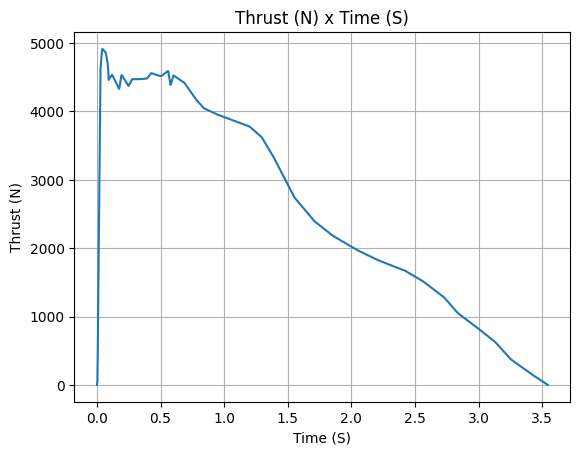

In [1]:
#%matplotlib widget
from rocketpy import Environment, SolidMotor, Rocket, Flight, Function
import datetime
import csv
import pandas as pd
import numpy as np
from rocketdefintions import JUMPStack,JUMPSustainer,JUMPSustainerNOMOTOR
from motordefintions import BoosterMotor,SustainerMotor
from openmeteo_environment import create_openmeteo_environment
# Launch site
# FAR
# Latitude: 35.3466 N
# Longitude: -117.809 W
# Altitude: 2000 ft

site_lat = 35.3466
site_lon = -117.809 
site_alt = 2000 #ft

launch_date = [2026,1,18,8,0,0]
timeadj = -4


# Launch site
# FAR
# Latitude: 35.3466 N
# Longitude: -117.809 W
# Altitude: 2000 ft

site_lat = 35.3466
site_lon = -117.809 
site_alt = 2000/3.281 #ft

# env = Environment()

# # Load the .csv file into the environment
# df = pd.read_csv('vertical_profile_2026-01-15_14PST copy.csv')

# #print(df)

# # Create Function objects to represent the profiles
# pressure_func = Function(np.column_stack([df['height'], df['pressure']]))
# temperature_func = Function(np.column_stack([df['height'], df['temperature']]))
# wind_u_func = Function(np.column_stack([df['height'], df['wind_u']]))
# wind_v_func = Function(np.column_stack([df['height'], df['wind_v']]))

# # Set up the environment

# env.set_atmospheric_model(
#     type="custom_atmosphere",
#     pressure=pressure_func,
#     temperature=temperature_func,
#     wind_u=wind_u_func,
#     wind_v=wind_v_func,
# )

# env = Environment(latitude=site_lat, longitude=site_lon, elevation=site_alt,timezone="US/Pacific",date=(2026, 5, 24, 8)) # year, month, day, hour
# # timezone="US/Pacific")

# # env.set_atmospheric_model(type="Forecast", file="GFS")

# env.set_atmospheric_model(type="Windy", file="GFS")



result = create_openmeteo_environment(
    latitude=35.3466,
    longitude=-117.809,
    date="2026-05-24",
    time="08:00",
    timezone_name="US/Pacific",
    elevation_m=2000 / 3.281,
)

env = result.environment

env.info()

BoosterMotor.info()


In [2]:


def quaternion_to_angle_from_vertical(e0, e1, e2, e3):
    """
    Convert quaternion to angle from vertical (zenith angle)
    
    Parameters:
    e0, e1, e2, e3: Quaternion components
    
    Returns:
    angle_degrees: Angle from vertical in degrees
    """
    # Normalize quaternion (just in case)
    norm = np.sqrt(e0**2 + e1**2 + e2**2 + e3**2)
    e0, e1, e2, e3 = e0/norm, e1/norm, e2/norm, e3/norm
    
    # The vertical direction in body frame after rotation
    # Original vertical is [0, 0, 1] (pointing up)
    # Apply quaternion rotation to get current vertical direction
    
    # Quaternion rotation formula for vector [0, 0, 1]
    vx = 2 * (e0*e2 + e1*e3)
    vy = 2 * (e1*e2 - e0*e3)
    vz = e0**2 - e1**2 - e2**2 + e3**2
    
    # Angle from vertical is the angle between [0, 0, 1] and [vx, vy, vz]
    # cos(angle) = dot product with [0, 0, 1] = vz
    angle_rad = np.arccos(np.clip(vz, -1, 1))
    angle_deg = np.degrees(angle_rad)
    
    return angle_deg

In [11]:
from rocketpy.plots.compare import CompareFlights
import numpy as np
import matplotlib as mpl
import multiprocessing

#monte carlo attempts
#just gonna vary launch angle for now

railinclination = [90,5]
railheading = [270,90]
flightnum = 1
thisflightnum = 0

flights = []
landingcoords = []

randomnum = np.random.normal(railinclination[0],railinclination[1],1)
print(randomnum)

def runsim():
    print("running sim")
    StackFlight2 = Flight(
        rocket=JUMPStack, 
        environment=env, 
        rail_length=40/3.281, 
        inclination=np.random.normal(railinclination[0],railinclination[1],1)[0],#np.random.normal(railinclination,inclinationstd,1), 
        heading=np.random.normal(railheading[0],railheading[1],1)[0],
        max_time = BoosterMotor.burn_out_time,
        rtol=1e-4,   # default is ~1e-6
        atol=1e-6,   # default is ~1e-9
        time_overshoot=True,
        )
    #print(BoosterMotor.burn_out_time)

    #StackFlight2.info()
    #StackFlight2.plots.trajectory_3d()
    flights.append(StackFlight2)

    boosterburnoutangle = quaternion_to_angle_from_vertical(StackFlight2.solution[-1][7],StackFlight2.solution[-1][8],StackFlight2.solution[-1][9],StackFlight2.solution[-1][10])

    #print("booster burnout at: " + str(boosterburnoutangle) + " on sim " + str(simid))

    if boosterburnoutangle > 14:
        return StackFlight2.solution

    maxstagingdelay = 15

    SustainerNOMOTORFlight2 = Flight(
        rocket=JUMPSustainerNOMOTOR, 
        environment=env, 
        initial_solution=StackFlight2,
        rail_length=0.01, 
        inclination=StackFlight2.attitude_angle(BoosterMotor.burn_out_time-0.01), 
        heading=StackFlight2.path_angle(BoosterMotor.burn_out_time-0.01),
        max_time = maxstagingdelay+BoosterMotor.burn_out_time,
        rtol=1e-4,   # default is ~1e-6
        atol=1e-6,   # default is ~1e-9
        time_overshoot=True
    )

    flights.append(SustainerNOMOTORFlight2)

    sustainerignitionangle = quaternion_to_angle_from_vertical(SustainerNOMOTORFlight2.solution[-1][7],SustainerNOMOTORFlight2.solution[-1][8],SustainerNOMOTORFlight2.solution[-1][9],SustainerNOMOTORFlight2.solution[-1][10])

    #print("sustainer ignition at: " + str(sustainerignitionangle) + " on sim " + str(simid))

    stagingtime = 0

    stagingdelay = 4.5

    stagingindex = 0
    
    for point in SustainerNOMOTORFlight2.solution:
        #print("running staging checker at time " + str(point[0]) + " at velocity " + str(point[6]))
        currentangle = quaternion_to_angle_from_vertical(point[7],point[8],point[9],point[10])
        if point[6] < 700/3.281 or currentangle > 9:
            stagingdelay = point[0]
            ignition_delay = stagingdelay - BoosterMotor.burn_out_time
            #print("found staging point at " + str(round(stagingdelay,2)) + "s, " + str(round(point[6],3)) + " m/s and " + str(round(currentangle,3)) + " deg; on sim " + str(simid))
            break
        elif point[6] < 300/3.281 or currentangle > 15:
            return SustainerNOMOTORFlight2.solution
    
        stagingindex = stagingindex+1

    #print("sustainer ignition at: " + str(stagingdelay) + " seconds on sim " + str(simid))

    

    sustainerstartcondition = SustainerNOMOTORFlight2.solution[stagingindex][:]
    sustainerstartcondition[0] = 0

    SustainerFlight2 = Flight(
        rocket=JUMPSustainer, 
        environment=env, 
        initial_solution=sustainerstartcondition,
        rail_length=0.01, 
        inclination=SustainerNOMOTORFlight2.attitude_angle(stagingdelay+BoosterMotor.burn_out_time-0.01), 
        heading=SustainerNOMOTORFlight2.path_angle(stagingdelay+BoosterMotor.burn_out_time-0.01),
        rtol=1e-4,   # default is ~1e-6
        atol=1e-6,   # default is ~1e-9
        time_overshoot=True
        #max_time = 15
    )
    for entry in SustainerFlight2.solution:
        entry[0] = entry[0]+stagingdelay+BoosterMotor.burn_out_time
    flights.append(SustainerFlight2)
    landingcoords.append([SustainerFlight2.x_impact,SustainerFlight2.y_impact])
    print(SustainerFlight2.apogee*3.281)
    print("ran sim")
    

    

while thisflightnum < flightnum:
    runsim()
    thisflightnum = thisflightnum + 1 
    print(thisflightnum)
    





[88.19218918]
running sim
142307.1312988408
ran sim
1


142307.1312988408
4.1477971510743865
295.05885690736744
1.9070472844837205


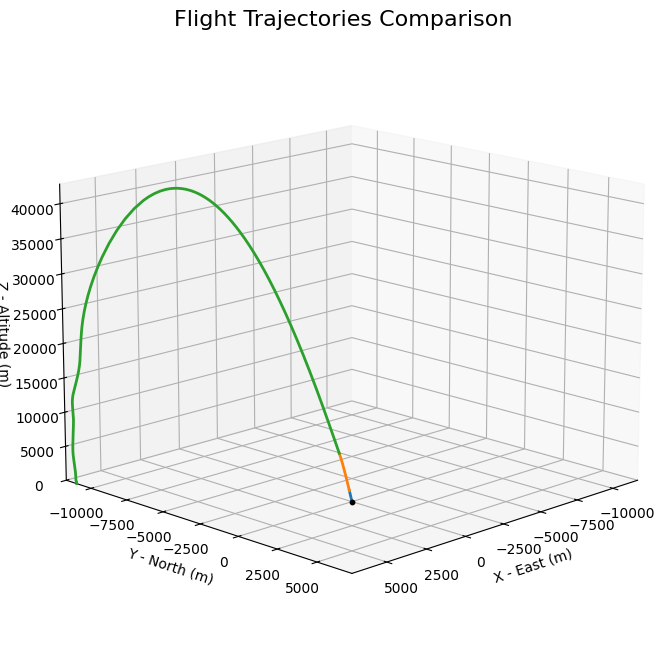

c:\Users\Ejfso\Documents\GitHub\Procyon\rocketpy\.venv\Lib\site-packages\rocketpy\plots\plot_helpers.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


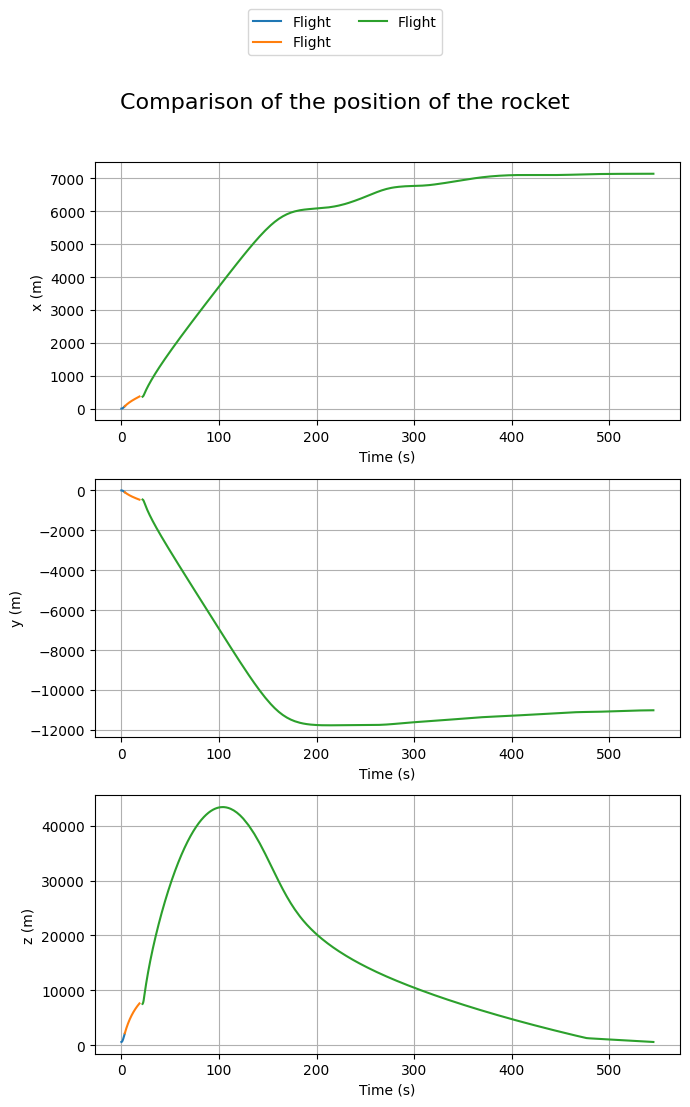

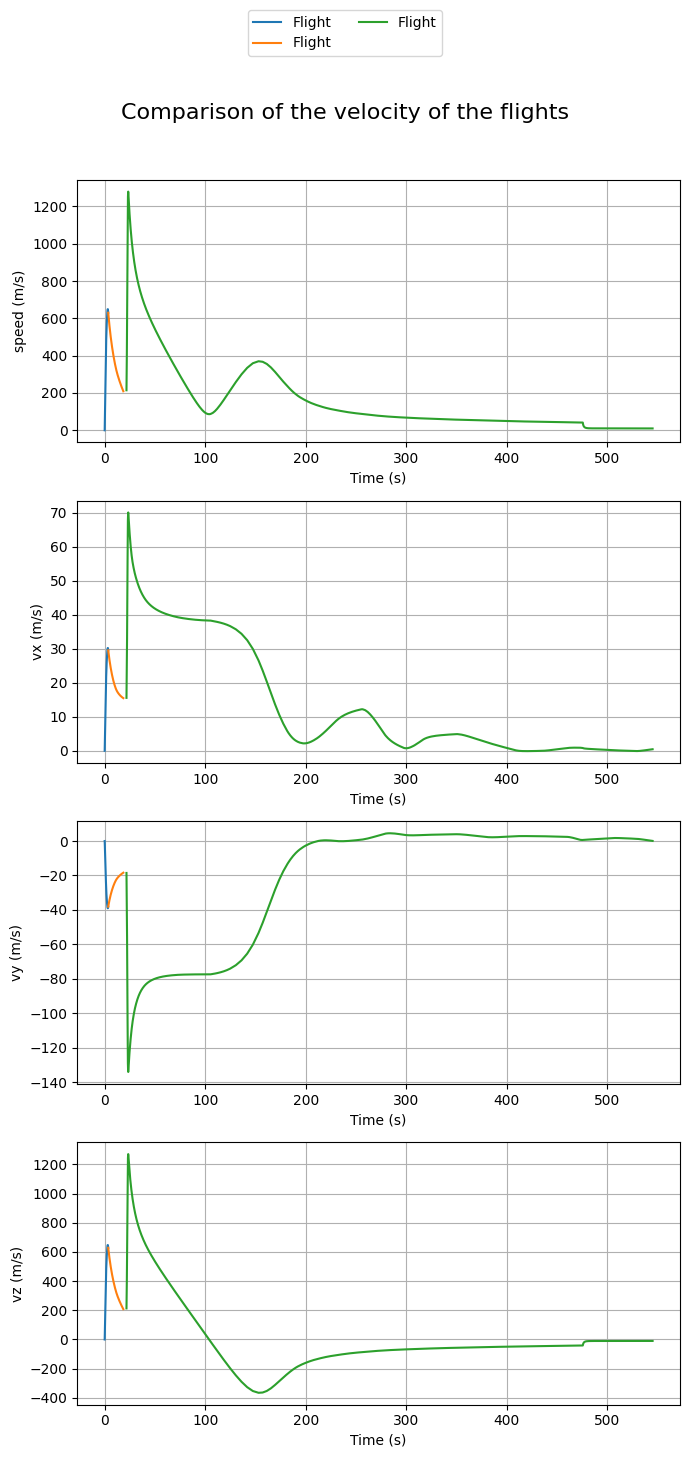

In [13]:
import matplotlib.pyplot as plt
#comparison.stability_margin()
print(flights[2].apogee*3.281)
print(flights[2].max_mach_number)
print(flights[0].out_of_rail_velocity*3.281)


print(flights[0].max_mach_number)
#print(landingcoords)
comparison = CompareFlights(flights)
# #SustainerFlight2.info()
comparison.trajectories_3d()
#comparison.trajectories_2d()
comparison.positions()

comparison.velocities()


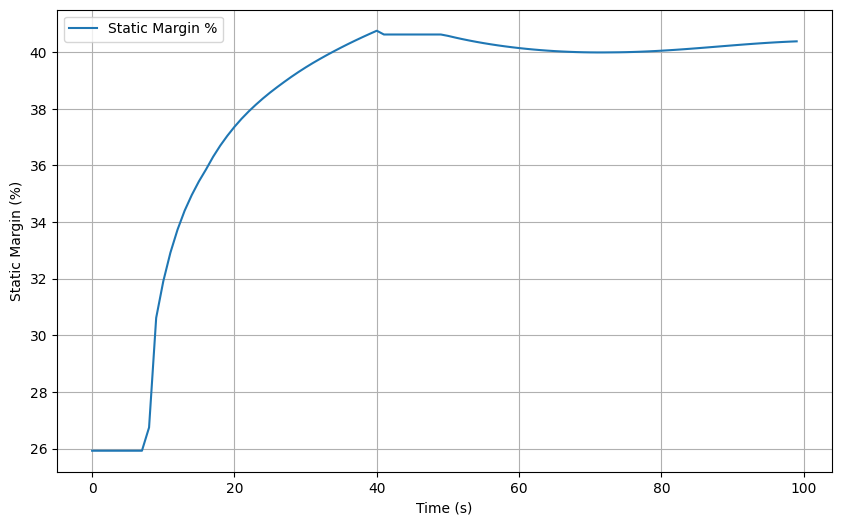

In [5]:
times = np.linspace(0, 100, 100)
sustainer_length = 1.5748 #m

# 2. Get CG over time
sustainer_cg_values = flights[2].rocket.center_of_mass(times-flights[2].solution[0][0])

#print(cg_values)

# 3. Get CP over time 
# Note: CP in RocketPy depends on Mach number. 
# We pull the Mach number from the flight at each time step.
cp_values = []
for t in times:
    mach = flights[2].mach_number(t)
    #print(mach)
    cp_t = flights[2].rocket.cp_position(mach)
    cp_values.append(cp_t)

static_margin_calced = ((sustainer_cg_values-cp_values)/sustainer_length)*100

# Plotting
plt.figure(figsize=(10, 6))
#plt.plot(cg_values, label='Center of Gravity (CG)')
#plt.plot(cp_values, label='Center of Pressure (CP)')
plt.plot(static_margin_calced, label='Static Margin %')
#plt.gca().invert_yaxis() 
plt.ylabel('Static Margin (%)')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True)
plt.show()

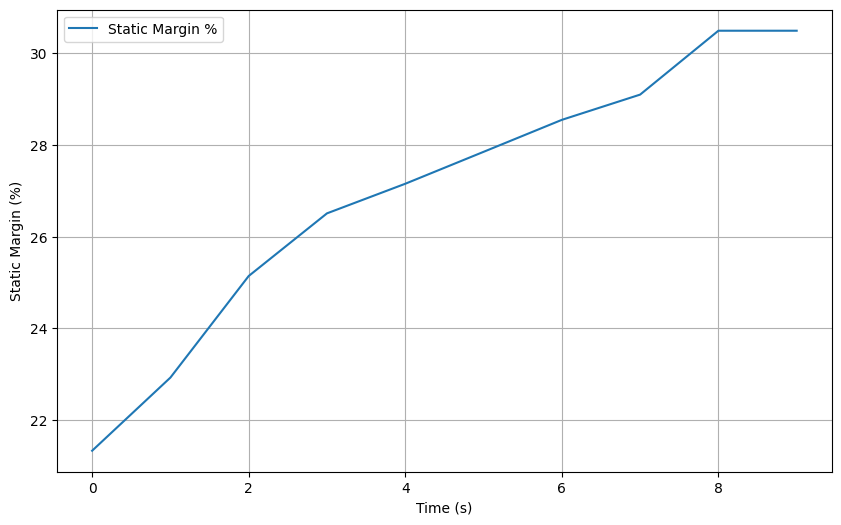

In [6]:
times = np.linspace(0, 4, 10)
stack_length = 3.0734 #m

# 2. Get CG over time
stack_cg_values = flights[0].rocket.center_of_mass(times)

#print(cg_values)

# 3. Get CP over time 
# Note: CP in RocketPy depends on Mach number. 
# We pull the Mach number from the flight at each time step.
cp_values = []
for t in times:
    mach = flights[0].mach_number(t)
    #print(mach)
    cp_t = flights[0].rocket.cp_position(mach)
    cp_values.append(cp_t)

static_margin_calced = ((stack_cg_values-cp_values)/stack_length)*100

# Plotting
plt.figure(figsize=(10, 6))
#plt.plot(cg_values, label='Center of Gravity (CG)')
#plt.plot(cp_values, label='Center of Pressure (CP)')
plt.plot(static_margin_calced, label='Static Margin %')
#plt.gca().invert_yaxis() 
plt.ylabel('Static Margin (%)')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True)
plt.show()